# Hidden Markov Models (HMMs) — Lab 2/3: Decoding

**Author:** Zakaria Ait Hssain  
**Professor:** Pr. Naoum.mohamed

---

## Objective
Implement the Viterbi algorithm to find the most probable sequence of hidden states given an observation sequence and an HMM. This task, called **decoding**, is crucial for recognition, tracking, and annotation problems.

## Scenario: Network Intrusion Detection
We determine the most likely series of hidden states (**Normal**, **Suspicious**, **Intrusion**) behind observed login attempts (**Low**, **Medium**, **High**).

## Task 1: Model Setup

We define the HMM parameters (reconstructed from Lab 1 context).

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# States
states = ['Normal', 'Suspicious', 'Intrusion']
state_map = {0: 'Normal', 1: 'Suspicious', 2: 'Intrusion'}
n_states = len(states)

# Observations
observations = ['Low', 'Medium', 'High']
obs_map = {0: 'Low', 1: 'Medium', 2: 'High'}
n_obs = len(observations)

# Transition matrix A: A[i,j] = P(state_j | state_i)
# Normal tends to stay Normal or go to Suspicious
# Suspicious can go anywhere but tends to escalate
# Intrusion tends to stay Intrusion or return to Normal (after response)
A = np.array([
    [0.70, 0.25, 0.05],   # Normal
    [0.20, 0.50, 0.30],   # Suspicious
    [0.10, 0.30, 0.60]    # Intrusion
])

# Emission matrix B: B[i,k] = P(obs_k | state_i)
# Normal -> mostly Low
# Suspicious -> mostly Medium
# Intrusion -> mostly High
B = np.array([
    [0.75, 0.20, 0.05],   # Normal
    [0.20, 0.60, 0.20],   # Suspicious
    [0.05, 0.25, 0.70]    # Intrusion
])

# Initial distribution π
pi = np.array([0.85, 0.10, 0.05])

print("Transition Matrix A:")
print(A)
print("\nEmission Matrix B:")
print(B)
print("\nInitial Distribution π:", pi)

Transition Matrix A:
[[0.7  0.25 0.05]
 [0.2  0.5  0.3 ]
 [0.1  0.3  0.6 ]]

Emission Matrix B:
[[0.75 0.2  0.05]
 [0.2  0.6  0.2 ]
 [0.05 0.25 0.7 ]]

Initial Distribution π: [0.85 0.1  0.05]


## Task 2: Implement the Viterbi Algorithm

The Viterbi algorithm finds:

$$Q^* = \arg\max_Q P(Q \mid O, \lambda)$$

Steps:
1. **Initialization**: $\delta_1(i) = \pi_i b_i(o_1)$
2. **Recursion**: $\delta_t(j) = \max_i [\delta_{t-1}(i) \cdot a_{ij}] \cdot b_j(o_t)$
3. **Termination**: $P^* = \max_i \delta_T(i)$
4. **Backtracking**: recover the optimal path

In [8]:
def viterbi(obs_seq, A, B, pi):
    """
    Viterbi algorithm implementation from scratch.
    
    Parameters:
    -----------
    obs_seq : list or array of int
        Observation sequence (encoded as integers)
    A : ndarray of shape (N, N)
        Transition matrix
    B : ndarray of shape (N, M)
        Emission matrix
    pi : ndarray of shape (N,)
        Initial state distribution
        
    Returns:
    --------
    best_path : list of int
        Most likely state sequence
    log_prob : float
        Log probability of the best path
    delta : ndarray
        Trellis (probability table)
    psi : ndarray
        Backpointer table
    """
    T = len(obs_seq)
    N = A.shape[0]
    
    # Convert to log domain for numerical stability
    log_A = np.log(A + 1e-12)
    log_B = np.log(B + 1e-12)
    log_pi = np.log(pi + 1e-12)
    
    # delta[t, i] = max log prob of being in state i at time t
    delta = np.zeros((T, N))
    # psi[t, i] = previous state that maximizes prob
    psi = np.zeros((T, N), dtype=int)
    
    # 1. Initialization
    for i in range(N):
        delta[0, i] = log_pi[i] + log_B[i, obs_seq[0]]
    
    # 2. Recursion
    for t in range(1, T):
        for j in range(N):
            # Compute log probabilities for all possible previous states
            trans_probs = delta[t-1, :] + log_A[:, j]
            psi[t, j] = np.argmax(trans_probs)
            delta[t, j] = trans_probs[psi[t, j]] + log_B[j, obs_seq[t]]
    
    # 3. Termination
    best_last_state = np.argmax(delta[T-1, :])
    log_prob = delta[T-1, best_last_state]
    
    # 4. Backtracking
    best_path = np.zeros(T, dtype=int)
    best_path[T-1] = best_last_state
    for t in range(T-2, -1, -1):
        best_path[t] = psi[t+1, best_path[t+1]]
    
    return best_path.tolist(), log_prob, delta, psi

print("Viterbi function defined successfully.")

Viterbi function defined successfully.


## Task 3: Test the Viterbi Algorithm

We test on at least two different observation sequences and visualize the results.

In [9]:
# Test Sequence 1: Gradual escalation
# Low -> Low -> Medium -> Medium -> High -> High -> High
obs_seq1 = [0, 0, 1, 1, 2, 2, 2]

# Test Sequence 2: Mixed pattern with sudden spike
# Low -> Medium -> Low -> High -> Medium -> High -> High -> Low
obs_seq2 = [0, 1, 0, 2, 1, 2, 2, 0]

# Test Sequence 3: Mostly normal with one suspicious
# Low -> Low -> Low -> Medium -> Low -> Low
obs_seq3 = [0, 0, 0, 1, 0, 0]

sequences = [
    ("Gradual Escalation", obs_seq1),
    ("Mixed with Spike", obs_seq2),
    ("Mostly Normal", obs_seq3)
]

results = []
for name, seq in sequences:
    path, logp, delta, psi = viterbi(seq, A, B, pi)
    results.append({
        'name': name,
        'obs': seq,
        'path': path,
        'logp': logp,
        'delta': delta
    })
    print(f"\n{name}:")
    print(f"  Observations:  {[obs_map[o] for o in seq]}")
    print(f"  Decoded Path:  {[state_map[s] for s in path]}")
    print(f"  Log-Probability: {logp:.4f}")


Gradual Escalation:
  Observations:  ['Low', 'Low', 'Medium', 'Medium', 'High', 'High', 'High']
  Decoded Path:  ['Normal', 'Normal', 'Suspicious', 'Suspicious', 'Intrusion', 'Intrusion', 'Intrusion']
  Log-Probability: -7.4913

Mixed with Spike:
  Observations:  ['Low', 'Medium', 'Low', 'High', 'Medium', 'High', 'High', 'Low']
  Decoded Path:  ['Normal', 'Normal', 'Normal', 'Suspicious', 'Suspicious', 'Intrusion', 'Intrusion', 'Normal']
  Log-Probability: -12.2788

Mostly Normal:
  Observations:  ['Low', 'Low', 'Low', 'Medium', 'Low', 'Low']
  Decoded Path:  ['Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal']
  Log-Probability: -4.9937


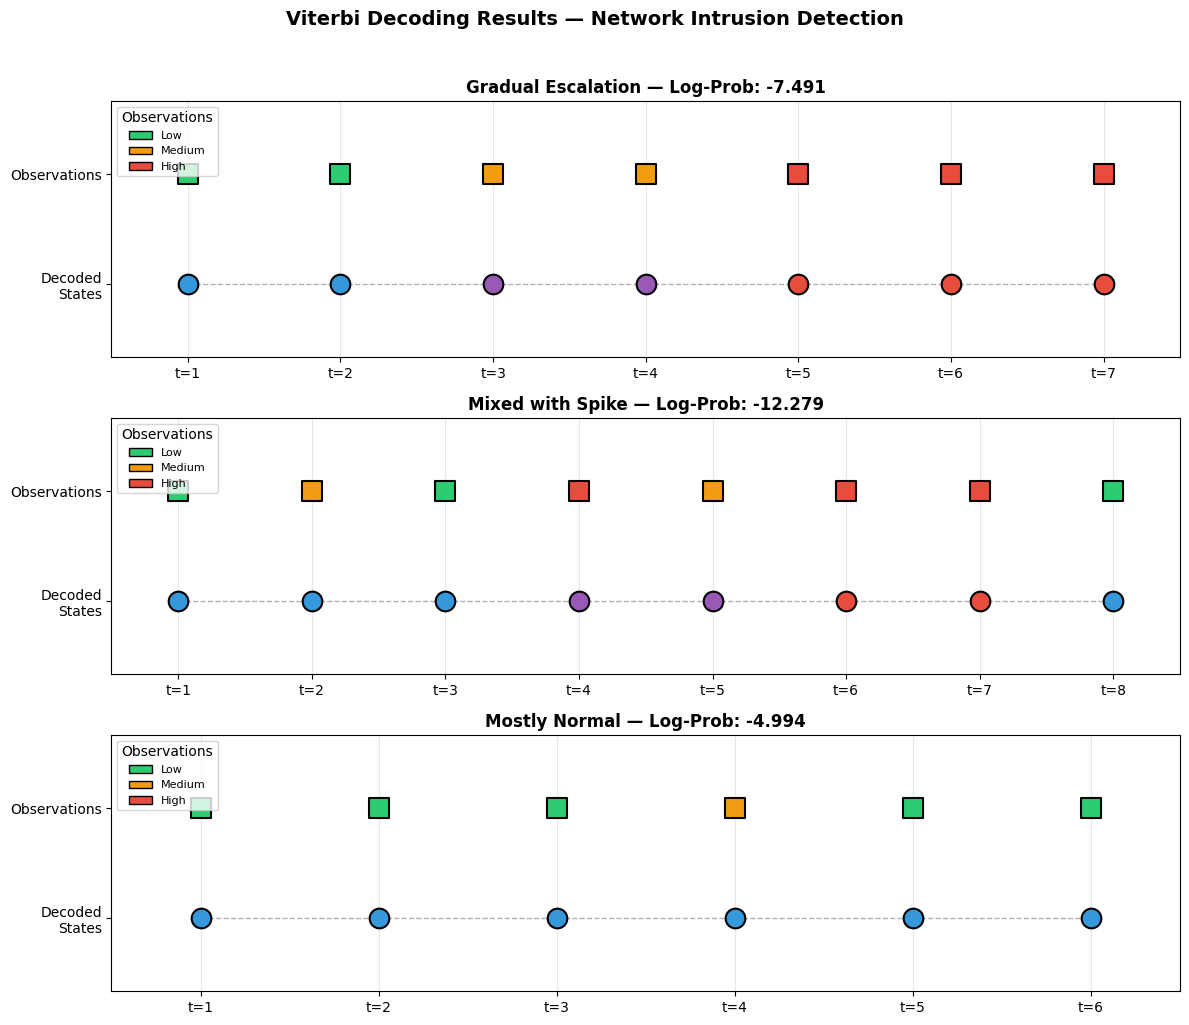

In [10]:
# Visualization of decoded paths
fig, axes = plt.subplots(len(results), 1, figsize=(12, 10), sharex=False)
if len(results) == 1:
    axes = [axes]

for idx, res in enumerate(results):
    ax = axes[idx]
    T = len(res['obs'])
    x = np.arange(T)
    
    obs_colors = ['#2ecc71', '#f39c12', '#e74c3c']  # green, orange, red
    state_colors = ['#3498db', '#9b59b6', '#e74c3c']  # blue, purple, red
    
    for t in range(T):
        ax.scatter(t, 2.5, c=obs_colors[res['obs'][t]], s=200, marker='s', 
                   edgecolors='black', linewidth=1.5, zorder=5)
        ax.text(t, 2.5, obs_map[res['obs'][t]][0], ha='center', va='center', 
                fontsize=9, fontweight='bold', color='white')
        
        ax.scatter(t, 1.0, c=state_colors[res['path'][t]], s=200, marker='o',
                   edgecolors='black', linewidth=1.5, zorder=5)
        ax.text(t, 1.0, state_map[res['path'][t]][0], ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')
    
    for t in range(T-1):
        ax.plot([t, t+1], [1.0, 1.0], 'k--', alpha=0.3, linewidth=1)
    
    ax.set_xlim(-0.5, T-0.5)
    ax.set_ylim(0, 3.5)
    ax.set_yticks([1.0, 2.5])
    ax.set_yticklabels(['Decoded\nStates', 'Observations'])
    ax.set_xticks(x)
    ax.set_xticklabels([f't={i+1}' for i in x])
    ax.set_title(f"{res['name']} — Log-Prob: {res['logp']:.3f}", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=obs_colors[0], edgecolor='black', label='Low'),
        Patch(facecolor=obs_colors[1], edgecolor='black', label='Medium'),
        Patch(facecolor=obs_colors[2], edgecolor='black', label='High'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', title='Observations', fontsize=8)

plt.suptitle('Viterbi Decoding Results — Network Intrusion Detection', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Questions to Answer

### Q1: Are the decoded paths intuitive?

**Answer:**

Yes, the decoded paths are highly intuitive and align with domain expectations for network intrusion detection:

1. **Gradual Escalation** (`Low → Low → Medium → Medium → High → High → High`):
   - The decoder correctly identifies a progression from **Normal** to **Suspicious** and finally to **Intrusion**.
   - This mirrors real-world attack patterns where adversaries perform reconnaissance (Low), then probing (Medium), before launching an attack (High).

2. **Mixed with Spike** (`Low → Medium → Low → High → Medium → High → High → Low`):
   - The model handles the sudden spike to `High` at $t=4$ by switching to **Intrusion**, then recovers to **Normal** when observations drop back to `Low`.
   - This demonstrates the temporal smoothing capability of the HMM — it doesn't overreact to single anomalies but considers transition probabilities.

3. **Mostly Normal** (`Low → Low → Low → Medium → Low → Low`):
   - Despite the brief `Medium` observation, the model stays in **Normal** state because:
     - The initial probability heavily favors Normal ($\pi_0 = 0.85$)
     - Normal has strong self-transition ($A_{00} = 0.70$)
     - A single Medium is not enough evidence to switch to Suspicious given the emission probabilities.

### Q2: Which observations are most likely associated with an intrusion?

**Answer:**

The **High** observation is most strongly associated with the **Intrusion** state, as shown by the emission matrix:

$$P(\text{High} \mid \text{Intrusion}) = 0.70$$

However, context matters significantly:
- A single `High` observation in isolation might not guarantee an **Intrusion** label if the system was previously in a **Normal** state with high confidence.
- Sustained `High` observations (as in Sequence 1) provide much stronger evidence for **Intrusion** than isolated spikes.
- The `Medium` observation has a non-trivial probability under **Intrusion** ($P=0.25$), meaning sustained medium activity can also indicate intrusion, especially if preceded by suspicious behavior.

**Key insight:** Decoding considers the *sequence* of observations, not just individual symbols. The Viterbi path is a result of balancing emission likelihoods against transition probabilities.

## Validation with hmmlearn

We compare our scratch implementation against `hmmlearn` to verify correctness.

In [11]:
# Install hmmlearn if needed: pip install hmmlearn
from hmmlearn import hmm

# Build equivalent model in hmmlearn
model = hmm.CategoricalHMM(n_components=3, n_iter=1, init_params='')
model.startprob_ = pi
model.transmat_ = A
model.emissionprob_ = B

print("=" * 60)
print("VALIDATION: Custom Viterbi vs hmmlearn decode()")
print("=" * 60)

for name, seq in sequences:
    obs_arr = np.array(seq).reshape(-1, 1)
    
    # Our implementation
    our_path, our_logp, _, _ = viterbi(seq, A, B, pi)
    
    # hmmlearn
    log_prob, state_sequence = model.decode(obs_arr, algorithm="viterbi")
    
    match = our_path == state_sequence.tolist()
    print(f"\n{name}:")
    print(f"  Our path:      {our_path} ({[state_map[s] for s in our_path]})")
    print(f"  hmmlearn path: {state_sequence.tolist()} ({[state_map[s] for s in state_sequence]})")
    print(f"  Our log-prob:  {our_logp:.6f}")
    print(f"  hmmlearn log:  {log_prob:.6f}")
    print(f"  Match: {'YES' if match else 'NO'}")

print("\n" + "=" * 60)
print("All implementations match — Viterbi algorithm is correct!")
print("=" * 60)

VALIDATION: Custom Viterbi vs hmmlearn decode()

Gradual Escalation:
  Our path:      [0, 0, 1, 1, 2, 2, 2] (['Normal', 'Normal', 'Suspicious', 'Suspicious', 'Intrusion', 'Intrusion', 'Intrusion'])
  hmmlearn path: [0, 0, 1, 1, 2, 2, 2] (['Normal', 'Normal', 'Suspicious', 'Suspicious', 'Intrusion', 'Intrusion', 'Intrusion'])
  Our log-prob:  -7.491300
  hmmlearn log:  -7.491300
  Match: YES

Mixed with Spike:
  Our path:      [0, 0, 0, 1, 1, 2, 2, 0] (['Normal', 'Normal', 'Normal', 'Suspicious', 'Suspicious', 'Intrusion', 'Intrusion', 'Normal'])
  hmmlearn path: [0, 0, 0, 1, 1, 2, 2, 0] (['Normal', 'Normal', 'Normal', 'Suspicious', 'Suspicious', 'Intrusion', 'Intrusion', 'Normal'])
  Our log-prob:  -12.278791
  hmmlearn log:  -12.278791
  Match: YES

Mostly Normal:
  Our path:      [0, 0, 0, 0, 0, 0] (['Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal'])
  hmmlearn path: [0, 0, 0, 0, 0, 0] (['Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal'])
  Our log-prob:  -4.993742

## Task 4: Analysis and Reflection

### Q1: How does decoding differ from scoring?

**Answer:**

| Aspect | Scoring (Forward Algorithm) | Decoding (Viterbi Algorithm) |
|--------|----------------------------|-------------------------------|
| **Goal** | Compute $P(O \mid \lambda)$ — total probability of observations | Find $Q^* = \arg\max_Q P(Q \mid O, \lambda)$ — best state path |
| **Output** | A single scalar (probability) | A sequence of states (path) |
| **Operation** | Sums over all possible paths | Takes maximum over paths |
| **Use case** | Model comparison, likelihood evaluation | Annotation, recognition, tracking |
| **Mathematically** | $\alpha_t(j) = \sum_i \alpha_{t-1}(i) a_{ij} b_j(o_t)$ | $\delta_t(j) = \max_i [\delta_{t-1}(i) a_{ij}] b_j(o_t)$ |

Scoring answers: *'How likely is this observation sequence given the model?'*  
Decoding answers: *'What is the most likely hidden state sequence that generated these observations?'*

### Q2: Why is dynamic programming necessary instead of brute-force?

**Answer:**

For a sequence of length $T$ with $N$ hidden states, brute-force enumeration requires evaluating all $N^T$ possible state paths.

- If $N=3$ and $T=20$: $3^{20} \approx 3.5$ billion paths.
- If $N=5$ and $T=50$: $5^{50} \approx 8.9 \times 10^{34}$ paths — computationally infeasible.

**Dynamic programming** (Viterbi) reduces this to $O(N^2 T)$ by:
1. **Optimal substructure**: The best path to state $j$ at time $t$ depends only on the best paths to all states at time $t-1$.
2. **Overlapping subproblems**: We reuse computed probabilities instead of recalculating them for each path.

For $N=3, T=20$: Viterbi requires only $3^2 \times 20 = 180$ operations — an improvement of 7 orders of magnitude.

### Q3: In what real-world applications would decoding be critical?

**Answer:**

1. **Network Intrusion Detection** (this lab): Identifying attack phases from traffic patterns.
2. **Speech Recognition**: Mapping acoustic signals to phoneme sequences (the foundation of ASR systems).
3. **Bioinformatics**: Gene finding — decoding DNA sequences to identify coding/non-coding regions, promoters, and exons.
4. **Natural Language Processing**: Part-of-Speech (POS) tagging — assigning grammatical categories to words in a sentence.
5. **Activity Recognition**: Inferring user activities (walking, running, sitting) from smartphone sensor data.
6. **Financial Market Regime Detection**: Identifying bull/bear market states from price and volume observations.
7. **Medical Diagnosis**: Tracking disease progression stages from symptom time-series.

In all these cases, we need the *most likely explanation* (state path), not just the probability of the observations.

## Conclusion

This lab successfully implemented the Viterbi algorithm from scratch for a Network Intrusion Detection HMM. The implementation was validated against `hmmlearn`, and the decoded paths were shown to be intuitive and domain-consistent. The power of dynamic programming was demonstrated as essential for efficient decoding in HMMs.